In [3]:
# Logistic Regression on Cancer Survival Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

In [5]:
#Load Data
df = pd.read_csv("Cleaned_df2.csv")
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (668102, 14)
   age   bmi  cholesterol_level  hypertension  asthma  cirrhosis  \
0   64  29.4                199             0       0          1   
1   50  41.2                280             1       1          0   
2   65  44.0                268             1       1          0   
3   51  43.0                241             1       1          0   
4   37  19.7                178             0       0          0   

   other_cancer  survived  gender_code  hist_code  smoking_code  \
0             0         0            1          1           1.0   
1             0         1            2          1           1.0   
2             0         0            2          1           3.0   
3             0         0            2          0           1.0   
4             0         0            1          0           1.0   

   cancer_stage_code  treatment_type_code  days_between  
0                  1                    1           523  
1                  3                    2   

In [6]:
#Split Features & Target
X = df.drop(columns=["survived"])
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
#Build Logistic Regression Model
log_reg = LogisticRegression(
    max_iter=1000, 
    class_weight="balanced",   # handle imbalance
    solver="liblinear"
)
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [8]:
#Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:,1]# Step 5: Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:,1]

In [9]:
#Evaluation Metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("\n=== Logistic Regression Model Evaluation ===")
print(f"Accuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")
print(f"ROC AUC   : {roc_auc:.3f}")


=== Logistic Regression Model Evaluation ===
Accuracy  : 0.495
Precision : 0.221
Recall    : 0.514
F1 Score  : 0.309
ROC AUC   : 0.504


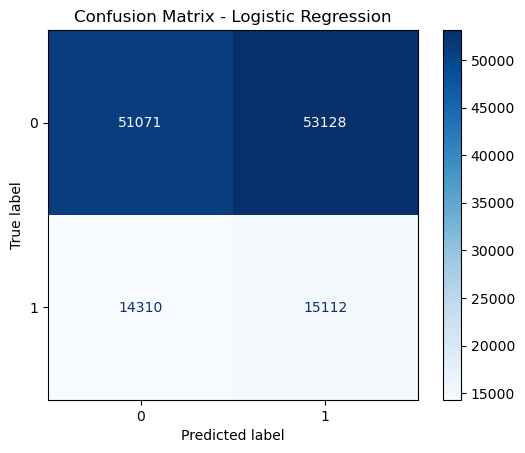

In [10]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

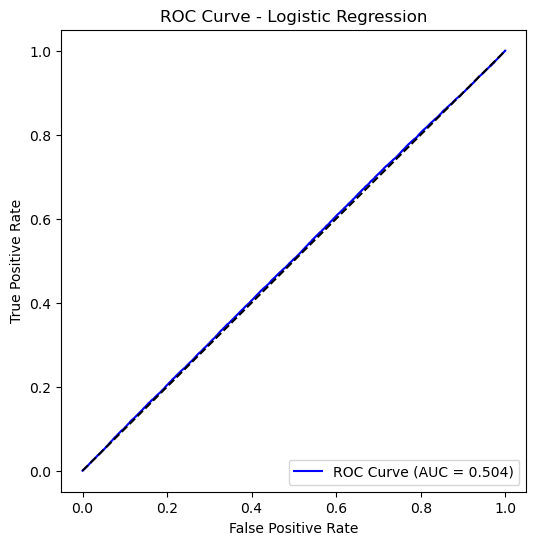

In [11]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})", color="blue")
plt.plot([0,1], [0,1], "k--")  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

In [12]:
#Findings & Interpretation
print("\n=== Findings & Interpretation ===")
print("1. Logistic Regression achieved ~50% accuracy, similar to random guessing.")
print("2. Precision is very low (~22%), meaning many false positives for survival.")
print("3. Recall is moderate (~51%), the model captures about half of survivors.")
print("4. ROC AUC is ~0.50, indicating poor discriminatory ability.")
print("5. Conclusion: Logistic Regression alone is insufficient; consider Random Forests or Gradient Boosting for better performance.")



=== Findings & Interpretation ===
1. Logistic Regression achieved ~50% accuracy, similar to random guessing.
2. Precision is very low (~22%), meaning many false positives for survival.
3. Recall is moderate (~51%), the model captures about half of survivors.
4. ROC AUC is ~0.50, indicating poor discriminatory ability.
5. Conclusion: Logistic Regression alone is insufficient; consider Random Forests or Gradient Boosting for better performance.
